In [ ]:
!pip -q install biopython requests

import re
import numpy as np
import pandas as pd
import requests

from Bio.PDB import PDBParser
from Bio import SeqIO
from Bio.Align import PairwiseAligner
from scipy.spatial.distance import cdist
from scipy.stats import mannwhitneyu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# 0) Imports
# =========================
import json
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# =========================
# 1) Load JSON
# =========================

json_path = "/content/drive/MyDrive/HackRare/ANKRD11_KBGS_individuals.json"

data = json.loads(Path(json_path).read_text())

print("Top-level keys:", list(data.keys()))
print("cohortType:", data.get("cohortType"))
print("# diseases:", len(data.get("diseaseList", [])))
print("# HPO headers:", len(data.get("hpoHeaders", [])))
print("# individuals (rows):", len(data.get("rows", [])))

# =========================
# 2) Disease table
# =========================
disease_rows = []
for d in data.get("diseaseList", []):
    moi = d.get("modeOfInheritanceList", [])
    genes = d.get("geneTranscriptList", [])
    disease_rows.append({
        "diseaseId": d.get("diseaseId"),
        "diseaseLabel": d.get("diseaseLabel"),
        "moi": "; ".join([f"{x.get('hpoId')}|{x.get('hpoLabel')}" for x in moi]) if moi else None,
        "moi_citations": "; ".join([x.get("citation","") for x in moi if x.get("citation")]) if moi else None,
        "genes": "; ".join([f"{g.get('geneSymbol')}({g.get('hgncId')})|{g.get('transcript')}" for g in genes]) if genes else None,
    })

df_diseases = pd.DataFrame(disease_rows).sort_values(["diseaseId", "diseaseLabel"]).reset_index(drop=True)
display(df_diseases.head(10))

# =========================
# 3) HPO headers table (defines phenotype column order)
# =========================
df_hpo_headers = pd.DataFrame(data.get("hpoHeaders", []))
df_hpo_headers["hpo_idx"] = np.arange(len(df_hpo_headers))
display(df_hpo_headers.head(10))

# convenient lookups
hpo_ids = df_hpo_headers["hpoId"].tolist()
hpo_labels = df_hpo_headers["hpoLabel"].tolist()
hpo_id_by_idx = dict(zip(df_hpo_headers["hpo_idx"], df_hpo_headers["hpoId"]))
hpo_label_by_idx = dict(zip(df_hpo_headers["hpo_idx"], df_hpo_headers["hpoLabel"]))

# =========================
# 4) Individual table + disease assignments
# =========================
individual_rows = []
individual_diseases = []

for r in data.get("rows", []):
    ind = r.get("individualData", {})
    individual_rows.append({
        "individualId": ind.get("individualId"),
        "sex": ind.get("sex"),
        "pmid": ind.get("pmid"),
        "title": ind.get("title"),
        "comment": ind.get("comment"),
        "ageOfOnset": ind.get("ageOfOnset"),
        "ageAtLastEncounter": ind.get("ageAtLastEncounter"),
        "deceased": ind.get("deceased"),
    })

    for did in r.get("diseaseIdList", []) or []:
        individual_diseases.append({
            "individualId": ind.get("individualId"),
            "diseaseId": did
        })

df_individuals = pd.DataFrame(individual_rows).drop_duplicates(subset=["individualId"]).reset_index(drop=True)
df_individual_diseases = pd.DataFrame(individual_diseases).drop_duplicates().reset_index(drop=True)

display(df_individuals.head(10))
display(df_individual_diseases.head(10))

# =========================
# 5) Allele / mutation table (long form)
# =========================
allele_rows = []
for r in data.get("rows", []):
    ind_id = (r.get("individualData") or {}).get("individualId")
    allele_map = r.get("alleleCountMap", {}) or {}
    for allele_key, count in allele_map.items():
        allele_rows.append({
            "individualId": ind_id,
            "alleleKey": allele_key,
            "alleleCount": int(count) if count is not None else None
        })

df_alleles = pd.DataFrame(allele_rows)
display(df_alleles.head(20))
print("Unique allele keys:", df_alleles["alleleKey"].nunique())

# optional: allele pivot (individual x alleleKey)
df_allele_matrix = df_alleles.pivot_table(
    index="individualId", columns="alleleKey", values="alleleCount", aggfunc="sum", fill_value=0
).reset_index()

print("Allele matrix shape:", df_allele_matrix.shape)
display(df_allele_matrix.head(5))

# =========================
# 6) Phenotype matrix from hpoData
# =========================
# Your JSON stores hpoData as a LIST aligned to hpoHeaders by index.
# Each element looks like {"type": "Observed"} / "Excluded" / "Na" :contentReference[oaicite:6]{index=6}

TYPE_TO_VALUE = {
    "Observed": 1,
    "Excluded": 0,
    "Na": np.nan,
    "NA": np.nan,
    None: np.nan
}

pheno_rows = []
for r in data.get("rows", []):
    ind_id = (r.get("individualData") or {}).get("individualId")
    hpo_data = r.get("hpoData", []) or []

    # Safety: if lengths mismatch, pad/truncate to header length
    if len(hpo_data) < len(hpo_ids):
        hpo_data = hpo_data + [{"type": "Na"}] * (len(hpo_ids) - len(hpo_data))
    elif len(hpo_data) > len(hpo_ids):
        hpo_data = hpo_data[:len(hpo_ids)]

    row = {"individualId": ind_id}
    for idx, cell in enumerate(hpo_data):
        t = (cell or {}).get("type")
        val = TYPE_TO_VALUE.get(t, np.nan)
        # use HPO ID as column name (stable) — labels can be kept separately
        row[hpo_ids[idx]] = val
    pheno_rows.append(row)

df_pheno = pd.DataFrame(pheno_rows)

print("Phenotype matrix shape:", df_pheno.shape)
display(df_pheno.head(5))

# Add helpful summary stats: missingness per HPO term
missingness = df_pheno.drop(columns=["individualId"]).isna().mean().sort_values(ascending=False)
display(missingness.head(20).to_frame("missing_rate"))

# =========================
# 7) Merge into a single "modeling-ready" table (individual + disease + alleles + phenotypes)
# =========================
# If an individual can have multiple diseases, you can keep df_individual_diseases as separate
# and merge later, or for now assume one disease per person and pick the first.
df_one_disease = (df_individual_diseases
                  .sort_values(["individualId", "diseaseId"])
                  .groupby("individualId", as_index=False)
                  .first()
                 )

df_model = df_individuals.merge(df_one_disease, on="individualId", how="left") \
                         .merge(df_allele_matrix, on="individualId", how="left") \
                         .merge(df_pheno, on="individualId", how="left")

print("Model table shape:", df_model.shape)
display(df_model.head(5))

# =========================
# 8) Convenience: map HPO ID -> label (for UI / explanations)
# =========================
hpo_label_map = dict(zip(df_hpo_headers["hpoId"], df_hpo_headers["hpoLabel"]))

# Example: get observed HPO terms for one individual
def observed_terms(individual_id: str):
    row = df_pheno[df_pheno["individualId"] == individual_id]
    if row.empty:
        return []
    r = row.iloc[0].drop(labels=["individualId"])
    obs = r[r == 1].index.tolist()
    return [(h, hpo_label_map.get(h, "")) for h in obs]

example_id = df_individuals["individualId"].iloc[0]
print("Example individual:", example_id)
print("Observed terms:", observed_terms(example_id)[:15])

Top-level keys: ['cohortType', 'diseaseList', 'hpoHeaders', 'rows', 'hgvsVariants', 'structuralVariants', 'intergenicVariants', 'phetoolsSchemaVersion', 'hpoVersion', 'cohortAcronym', 'curationHistory']
cohortType: mendelian
# diseases: 1
# HPO headers: 48
# individuals (rows): 333


,diseaseId,diseaseLabel,moi,moi_citations,genes
0,OMIM:148050,KBG syndrome,HP:0000006|Autosomal dominant inheritance,PMID:36446582,ANKRD11(HGNC:21316)|NM_013275.6


,hpoLabel,hpoId,hpo_idx
0,Intellectual disability,HP:0001249,0
1,Autistic behavior,HP:0000729,1
2,Attention deficit hyperactivity disorder,HP:0007018,2
3,Global developmental delay,HP:0001263,3
4,Macrodontia,HP:0001572,4
5,Triangular face,HP:0000325,5
6,Thick eyebrow,HP:0000574,6
7,Long philtrum,HP:0000343,7
8,Abnormality of the hand,HP:0001155,8
9,Short stature,HP:0004322,9


,individualId,sex,pmid,title,comment,ageOfOnset,ageAtLastEncounter,deceased
0,KBG1,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
1,KBG2,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
2,KBG3,F,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
3,KBG4,F,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
4,KBG5,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
5,KBG64,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
6,KBG6,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
7,KBG10A,M,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
8,KBG10B,F,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na
9,KBG8A,F,PMID:36446582,"Clinical description, molecular delineation an...",na,na,na,na


,individualId,diseaseId
0,KBG1,OMIM:148050
1,KBG2,OMIM:148050
2,KBG3,OMIM:148050
3,KBG4,OMIM:148050
4,KBG5,OMIM:148050
5,KBG64,OMIM:148050
6,KBG6,OMIM:148050
7,KBG10A,OMIM:148050
8,KBG10B,OMIM:148050
9,KBG8A,OMIM:148050


...

,individualId,HP:0001249,HP:0000729,HP:0007018,HP:0001263,HP:0001572,HP:0000325,HP:0000574,HP:0000343,HP:0001155,HP:0004322,HP:0001511,HP:0002353,HP:0002750,HP:0001270,HP:0000750,HP:0002360,HP:0001252,HP:0002373,HP:0007359,HP:0002197,HP:0002121,HP:0006695,HP:0001655,HP:0001629,HP:0001631,HP:0001642,HP:0001647,HP:0000407,HP:0000405,HP:0000410,HP:0000403,HP:0011968,HP:0000028,HP:0000023,HP:0001537,HP:0000252,HP:0000294,HP:0000308,HP:0000303,HP:0002263,HP:0000486,HP:0000664,HP:0000316,HP:0000463,HP:0000414,HP:0000448,HP:0000411,HP:0000369
0,KBG1,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,1.0,0.0,NaN,0.0,NaN,1.0,NaN
1,KBG2,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,KBG3,NaN,NaN,NaN,1.0,1.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0
3,KBG4,1.0,NaN,NaN,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1.0,NaN,1.0,0.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,KBG5,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,1.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


,missing_rate
HP:0002121,0.990991
HP:0000410,0.987988
HP:0002373,0.972973
HP:0001655,0.969970
HP:0007359,0.945946
HP:0002197,0.936937
HP:0000369,0.849850
HP:0000448,0.846847
HP:0000303,0.837838
HP:0002263,0.825826


Model table shape: (333, 289)


,individualId,sex,pmid,title,comment,ageOfOnset,ageAtLastEncounter,deceased,diseaseId,ANKRD11_SV_16q24_1q24_3__86680657_89578069_x1,ANKRD11_SV_16q24_2_24_3_87498264_89596942_x1,ANKRD11_SV_16q24_2_24_3_87954851_89484166_x1,ANKRD11_SV_16q24_2_24_3_88230961_89363602_x1,ANKRD11_SV_16q24_2_q24_3_87925812_89521860_x1,ANKRD11_SV_16q24_2_q24_3_88230961_89383486_x1,ANKRD11_SV_16q24_2_q24_3_88621654_89383486_x1,ANKRD11_SV_16q24_2_q24_3_88666177_89472627_x1,ANKRD11_SV_16q24_2_q24_3__87183661_89520803_x1,ANKRD11_SV_16q24_2_q24_3__87340135_89335428_x1,ANKRD11_SV_16q24_2_q24_3__88230760_89363742_x1,ANKRD11_SV_16q24_2_q24_3__88230961_89363602_x1,ANKRD11_SV_16q24_2_q24_3__88556191_89557911_x1,ANKRD11_SV_16q24_2_q24_3__88630607_89607742_x1,ANKRD11_SV_16q24_2_q24_3__88635000_89628950_x1,ANKRD11_SV_16q24_2_q24_3__88641808_89332049_x1,ANKRD11_SV_16q24_2_q24_3__88755312_89584412_x1,ANKRD11_SV_16q24_2_q24_3__89283689_89429735_x1,ANKRD11_SV_16q24_2q24_3_87652026_89507330_x1,ANKRD11_SV_16q24_2q24_3__87502161_89688617_x3,ANKRD11_SV_16q24_3_87800226_89559330_x1,ANKRD11_SV_16q24_3_87_92_88_10_,ANKRD11_SV_16q24_3_88231090_89388103_x1,ANKRD11_SV_16q24_3_88763460_89344049_x1,ANKRD11_SV_16q24_3_88809983_89472627_x1,ANKRD11_SV_16q24_3_88854757_89520963_x1,ANKRD11_SV_16q24_3_88854757_89577705_x1,ANKRD11_SV_16q24_3_89122739_89501030_x1,ANKRD11_SV_16q24_3_89161684_89505106_x1,ANKRD11_SV_16q24_3_89199607_89472627_x1,ANKRD11_SV_16q24_3_89249149_89376186_x1,ANKRD11_SV_16q24_3_89256478_89506223_x1,ANKRD11_SV_16q24_3_89261399_89419131_x1,ANKRD11_SV_16q24_3_89261814_89556020_x3,ANKRD11_SV_16q24_3_89273092_89538759_x1,ANKRD11_SV_16q24_3_89273092_89577046_x1,ANKRD11_SV_16q24_3_89283689_89572450_x1,ANKRD11_SV_16q24_3_89283689_89579130_x1,ANKRD11_SV_16q24_3_89283689_89603390_x1,ANKRD11_SV_16q24_3_89295307_89559189_x1,ANKRD11_SV_16q24_3_89295307_89660379_x1,ANKRD11_SV_16q24_3_89315698_89548093_x1,ANKRD11_SV_16q24_3_89325387_89409147_x1,ANKRD11_SV_16q24_3_89328477_89477051_x1,ANKRD11_SV_16q24_3_89332453_89371851_x1,ANKRD11_SV_16q24_3_89335426_89371803_x1,ANKRD11_SV_16q24_3_89336307_89354085_x1,ANKRD11_SV_16q24_3_89343893_89497947_x1,ANKRD11_SV_16q24_3_89343893_89555548_x1,ANKRD11_SV_16q24_3_89343893_89584394_x1,ANKRD11_SV_16q24_3_89349711_89607741_x1,ANKRD11_SV_16q24_3_89349966_89593853_x1,ANKRD11_SV_16q24_3_89350931_89439639_x3,ANKRD11_SV_16q24_3_89359701_89379306_x1,ANKRD11_SV_16q24_3_89371838_89607414_x1,ANKRD11_SV_16q24_3_89388113_89541926_x1,ANKRD11_SV_16q24_3_89435258_89553707_x1,ANKRD11_SV_16q24_3_89461583_89559189_x1,ANKRD11_SV_16q24_3_89475451_89652148_x1,ANKRD11_SV_16q24_3_89476167_89484721_x1,ANKRD11_SV_16q24_3_89525403_89553574_x1,ANKRD11_SV_16q24_3_89542695_89656251_x3,ANKRD11_SV_16q24_3_89547555_89556020_x1,ANKRD11_SV_16q24_3_89556618_89557004_x1,ANKRD11_SV_16q24_3_89_507776_89565_656_x1,ANKRD11_SV_16q24_3__89161684_89505106_x1,ANKRD11_SV_16q24_3__89335228_89472768_x1,ANKRD11_SV_16q24_3__89335428_89559189_x1,ANKRD11_SV_16q24_3__89343893_89565656_x1,ANKRD11_SV_16q24_3__89429676_89559189_x1,c1120GtoT_ANKRD11_NM_013275v6,c1173CtoG_ANKRD11_NM_013275v6,c1285_1286del_ANKRD11_NM_013275v6,c1318CtoT_ANKRD11_NM_013275v6,c1367_1370del_ANKRD11_NM_013275v6,c1381_1384del_ANKRD11_NM_013275v6,c1385_1388del_ANKRD11_NM_013275v6,c1389dup_ANKRD11_NM_013275v6,c1457CtoG_ANKRD11_NM_013275v6,c1460_1463del_ANKRD11_NM_013275v6,c1711_1723del_ANKRD11_NM_013275v6,c1731dup_ANKRD11_NM_013275v6,c1763CtoA_ANKRD11_NM_013275v6,c1785_1786delGCinsTT_ANKRD11_NM_013275v6,c1801CtoT_ANKRD11_NM_013275v6,c1846GtoT_ANKRD11_NM_013275v6,c1893dup_ANKRD11_NM_013275v6,c1903_1907del_ANKRD11_NM_013275v6,c1940_1941delinsT_ANKRD11_NM_013275v6,c1977CtoG_ANKRD11_NM_013275v6,c2092_2096del_ANKRD11_NM_013275v6,...,c5488GtoT_ANKRD11_NM_013275v6,c548_551del_ANKRD11_NM_013275v6,c5712_5713insT_ANKRD11_NM_013275v6,c5790CtoA_ANKRD11_NM_013275v6,c5889del_ANKRD11_NM_013275v6,c5953_5954del_ANKRD11_NM_013275v6,c5957_5958del_ANKRD11_NM_013275v6,c6015dup_ANKRD11_NM_013275v6,c6053_6057del_ANKRD11_NM_013275v6,c6071_6084del_ANKRD1

Example individual: KBG1
Observed terms: [('HP:0001249', 'Intellectual disability'), ('HP:0001263', 'Global developmental delay'), ('HP:0000325', 'Triangular face'), ('HP:0000574', 'Thick eyebrow'), ('HP:0000343', 'Long philtrum'), ('HP:0001511', 'Intrauterine growth retardation'), ('HP:0001270', 'Motor delay'), ('HP:0000750', 'Delayed speech and language development'), ('HP:0001252', 'Hypotonia'), ('HP:0001655', 'Patent foramen ovale'), ('HP:0011968', 'Feeding difficulties'), ('HP:0000308', 'Microretrognathia'), ('HP:0000664', 'Synophrys'), ('HP:0000411', 'Protruding ear')]


In [ ]:
# =========================
# Build df_mut from df_alleles
# =========================

df_mut = df_alleles.copy()

# basic cleanup
df_mut = df_mut.dropna(subset=["alleleKey"]).drop_duplicates()
df_mut["alleleKey"] = df_mut["alleleKey"].astype(str)

print("df_mut shape:", df_mut.shape)
print("Unique patients:", df_mut["individualId"].nunique())
print("Unique allele keys:", df_mut["alleleKey"].nunique())
display(df_mut.head(10))

df_mut shape: (333, 3)
Unique patients: 333
Unique allele keys: 232


,individualId,alleleKey,alleleCount
0,KBG1,ANKRD11_SV_16q24_3_89336307_89354085_x1,1
1,KBG2,c3590_3594del_ANKRD11_NM_013275v6,1
2,KBG3,c3590_3594del_ANKRD11_NM_013275v6,1
3,KBG4,c3334del_ANKRD11_NM_013275v6,1
4,KBG5,c6792dup_ANKRD11_NM_013275v6,1
5,KBG64,c2329_2332del_ANKRD11_NM_013275v6,1
6,KBG6,c5790CtoA_ANKRD11_NM_013275v6,1
7,KBG10A,c6968_6975del_ANKRD11_NM_013275v6,1
8,KBG10B,c2329_2332del_ANKRD11_NM_013275v6,1
9,KBG8A,c6628GtoT_ANKRD11_NM_013275v6,1


In [ ]:
import re
import numpy as np
import pandas as pd

# =========================
# Parse positions from alleleKey
# =========================

def parse_protein_pos(alleleKey: str):
    """
    Extract AA position from protein HGVS like:
    - p.Arg345Cys
    - p.R345C
    - p.(Arg345Cys)
    Returns int or nan
    """
    if alleleKey is None or pd.isna(alleleKey):
        return np.nan
    s = str(alleleKey)

    # common patterns: p.Arg345Cys, p.R345C, optionally with parentheses
    m = re.search(r"p\.?\(?[A-Za-z]{1,3}(\d+)[A-Za-z]{1,3}\)?", s)
    if m:
        return int(m.group(1))
    return np.nan

def parse_cdna_pos(alleleKey: str):
    """
    Extract cDNA coordinate from HGVS like:
    - c.1903_1907del
    - c1903_1907del
    Returns first coordinate as int or nan
    """
    if alleleKey is None or pd.isna(alleleKey):
        return np.nan
    s = str(alleleKey)

    m = re.search(r"c\.?(\d+)", s)
    if m:
        return int(m.group(1))
    return np.nan

def cdna_to_aa_pos(cdna_pos):
    if pd.isna(cdna_pos):
        return np.nan
    return int(np.ceil(cdna_pos / 3.0))

df_mut2 = df_mut.copy()

df_mut2["aa_pos_protein"] = df_mut2["alleleKey"].apply(parse_protein_pos)
df_mut2["cdna_pos"] = df_mut2["alleleKey"].apply(parse_cdna_pos)
df_mut2["aa_pos_cdna"] = df_mut2["cdna_pos"].apply(cdna_to_aa_pos)

# Prefer protein-derived AA position; fallback to cDNA-derived
df_mut2["aa_pos"] = df_mut2["aa_pos_protein"].combine_first(df_mut2["aa_pos_cdna"])

# quick mutation type heuristics (optional)
def is_truncating(s):
    s = str(s)
    return bool(re.search(r"(stop|ter|\*|nonsense|frameshift|fs|del|dup|ins)", s, flags=re.I))

def is_missense(s):
    s = str(s)
    # protein HGVS p.X123Y is missense-like if it looks like AA->AA change and not stop/fs
    if re.search(r"p\.?\(?[A-Za-z]{1,3}\d+[A-Za-z]{1,3}\)?", s) and not re.search(r"(ter|\*|fs|stop)", s, flags=re.I):
        return True
    return False

df_mut2["MISSENSE_like"] = df_mut2["alleleKey"].apply(is_missense).astype(int)
df_mut2["TRUNC_like"] = df_mut2["alleleKey"].apply(is_truncating).astype(int)

print("df_mut2 shape:", df_mut2.shape)
print("AA pos present:", df_mut2["aa_pos"].notna().sum(), "/", len(df_mut2))
print("AA pos range:", df_mut2["aa_pos"].min(), "to", df_mut2["aa_pos"].max())
display(df_mut2[["individualId","alleleKey","alleleCount","aa_pos","MISSENSE_like","TRUNC_like"]].head(15))

df_mut2 shape: (333, 9)
AA pos present: 256 / 333
AA pos range: 71.0 to 2612.0


,individualId,alleleKey,alleleCount,aa_pos,MISSENSE_like,TRUNC_like
0,KBG1,ANKRD11_SV_16q24_3_89336307_89354085_x1,1,NaN,0,0
1,KBG2,c3590_3594del_ANKRD11_NM_013275v6,1,1197.0,0,1
2,KBG3,c3590_3594del_ANKRD11_NM_013275v6,1,1197.0,0,1
3,KBG4,c3334del_ANKRD11_NM_013275v6,1,1112.0,0,1
4,KBG5,c6792dup_ANKRD11_NM_013275v6,1,2264.0,0,1
5,KBG64,c2329_2332del_ANKRD11_NM_013275v6,1,777.0,0,1
6,KBG6,c5790CtoA_ANKRD11_NM_013275v6,1,1930.0,0,0
7,KBG10A,c6968_6975del_ANKRD11_NM_013275v6,1,2323.0,0,1
8,KBG10B,c2329_2332del_ANKRD11_NM_013275v6,1,777.0,0,1
9,KBG8A,c6628GtoT_ANKRD11_NM_013275v6,1,2210.0,0,0


In [ ]:
lo, hi = int(df_pos["uniprot_pos"].min()), int(df_pos["uniprot_pos"].max())

in_window = df_mut2["aa_pos"].between(lo, hi)
print("9J0A motif window:", lo, "to", hi)
print("Variants in window:", int(in_window.sum()))
print("Patients with ≥1 variant in window:", df_mut2.loc[in_window, "individualId"].nunique())

display(df_mut2.loc[in_window, ["individualId","alleleKey","aa_pos","alleleCount","MISSENSE_like","TRUNC_like"]].head(50))

9J0A motif window: 345 to 368
Variants in window: 0
Patients with ≥1 variant in window: 0


,individualId,alleleKey,aa_pos,alleleCount,MISSENSE_like,TRUNC_like


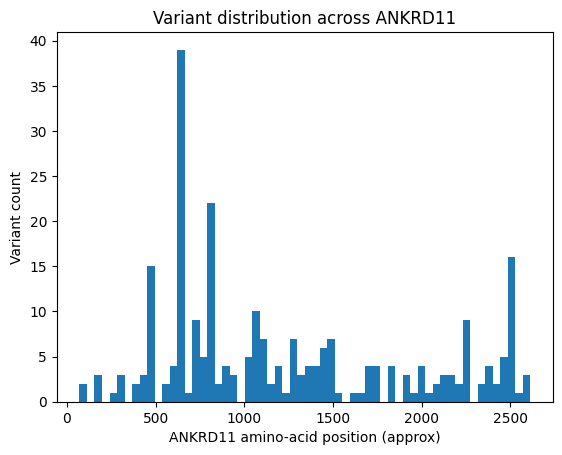

aa_pos min/max: 71 2612
Top hotspots (bin counts):
 533- 666: 45
 799- 932: 28
2396-2529: 25
1065-1198: 21
 400- 533: 18


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# keep only variants with aa_pos
x = df_mut2["aa_pos"].dropna().astype(int).values

plt.figure()
plt.hist(x, bins=60)
plt.xlabel("ANKRD11 amino-acid position (approx)")
plt.ylabel("Variant count")
plt.title("Variant distribution across ANKRD11")
plt.show()

print("aa_pos min/max:", int(np.min(x)), int(np.max(x)))
print("Top hotspots (bin counts):")
bins = np.linspace(1, 2663, 21).astype(int)  # 20 coarse bins
counts, edges = np.histogram(x, bins=bins)
for c, a, b in sorted(zip(counts, edges[:-1], edges[1:]), reverse=True)[:5]:
    print(f"{a:4d}-{b:4d}: {c}")

In [ ]:
from Bio.PDB import PDBParser
import numpy as np

# --------------------------------------------------
# 🔹 PUT YOUR GOOGLE DRIVE PATH HERE
# --------------------------------------------------
AF_PDB_PATH = "/content/drive/MyDrive/HackRare/AF-Q6UB99-F1-model_v6.pdb"
# --------------------------------------------------

parser = PDBParser(QUIET=True)
structure = parser.get_structure("ANKRD11_AF", AF_PDB_PATH)

# AlphaFold models are single model, single chain
model = next(structure.get_models())
chain = next(model.get_chains())

print("Loaded structure:", AF_PDB_PATH)
print("Chain ID:", chain.id)

Loaded structure: /content/drive/MyDrive/HackRare/AF-Q6UB99-F1-model_v6.pdb
Chain ID: A


In [ ]:
residues = []
ca_xyz = []
plddt = []
unip_pos = []

for res in chain.get_residues():
    hetflag, resseq, icode = res.get_id()

    if hetflag != " ":  # skip heteroatoms
        continue

    if "CA" not in res:
        continue

    residues.append(res)
    ca_xyz.append(res["CA"].coord.astype(float))

    # AlphaFold stores pLDDT in B-factor
    plddt.append(float(res["CA"].bfactor))

    # AlphaFold PDB numbering = UniProt numbering
    unip_pos.append(int(resseq))

ca_xyz = np.asarray(ca_xyz, dtype=float)
plddt = np.asarray(plddt, dtype=float)
unip_pos = np.asarray(unip_pos, dtype=int)

print("Total residues with CA:", len(residues))
print("UniProt position range:", unip_pos.min(), "to", unip_pos.max())
print("pLDDT summary:")
print("  Min:", np.min(plddt))
print("  Median:", np.median(plddt))
print("  Mean:", np.mean(plddt))
print("  Max:", np.max(plddt))

Total residues with CA: 2663
UniProt position range: 1 to 2663
pLDDT summary:
  Min: 17.77
  Median: 31.19
  Mean: 39.20781449493053
  Max: 96.44


In [ ]:
import numpy as np
import networkx as nx
from scipy.spatial import cKDTree

def build_confidence_graph(ca_xyz, unip_pos, plddt, cutoff_A=8.0, min_plddt_node=0.0):
    """
    Build CA contact graph with optional node filtering.
    Stores node attributes: unip_pos, plddt
    Stores edge attribute: dist
    """
    keep = plddt >= min_plddt_node
    idx_map = np.where(keep)[0]   # original indices kept
    xyz = ca_xyz[keep]
    pos = unip_pos[keep]
    conf = plddt[keep]

    G = nx.Graph(cutoff_A=float(cutoff_A), min_plddt_node=float(min_plddt_node))

    # add nodes (node id = original residue index in full arrays, so mapping stays easy)
    for orig_i, upos, c in zip(idx_map, pos, conf):
        G.add_node(int(orig_i), unip_pos=int(upos), plddt=float(c))

    # edges via KD-tree
    tree = cKDTree(xyz)
    pairs = tree.query_pairs(r=cutoff_A)  # pairs in "xyz index space"

    for i_small, j_small in pairs:
        i = int(idx_map[i_small])
        j = int(idx_map[j_small])
        dist = float(np.linalg.norm(ca_xyz[i] - ca_xyz[j]))
        G.add_edge(i, j, dist=dist)

    return G

# Graph over all residues
G_all = build_confidence_graph(ca_xyz, unip_pos, plddt, cutoff_A=8.0, min_plddt_node=0.0)

# Graph over structured core residues only
G_core = build_confidence_graph(ca_xyz, unip_pos, plddt, cutoff_A=8.0, min_plddt_node=70.0)

print("G_all  nodes/edges:", G_all.number_of_nodes(), G_all.number_of_edges())
print("G_core nodes/edges:", G_core.number_of_nodes(), G_core.number_of_edges())

G_all  nodes/edges: 2663 6911
G_core nodes/edges: 327 1354


In [ ]:
def region_nodes(G, plddt_lo=None, plddt_hi=None):
    out = set()
    for n, a in G.nodes(data=True):
        c = a["plddt"]
        if plddt_lo is not None and c < plddt_lo:
            continue
        if plddt_hi is not None and c > plddt_hi:
            continue
        out.add(n)
    return out

structured_nodes_all = region_nodes(G_all, plddt_lo=70.0)  # within G_all
disordered_nodes_all = region_nodes(G_all, plddt_hi=50.0)  # within G_all

print("Structured (>=70) nodes in G_all:", len(structured_nodes_all))
print("Disordered (<=50) nodes in G_all:", len(disordered_nodes_all))

Structured (>=70) nodes in G_all: 327
Disordered (<=50) nodes in G_all: 2232


In [ ]:
import random

def nodes_by_unip_range(G, lo, hi):
    return {n for n, a in G.nodes(data=True) if lo <= a["unip_pos"] <= hi}

def shortest_path_backbone(G, sources, targets, max_pairs=2000, top_k=200, seed=0):
    rng = random.Random(seed)
    sources = list(sources)
    targets = list(targets)
    if not sources or not targets:
        return set()

    pairs = [(s, t) for s in sources for t in targets]
    if len(pairs) > max_pairs:
        pairs = rng.sample(pairs, k=max_pairs)

    counts = {n: 0 for n in G.nodes()}
    for s, t in pairs:
        try:
            path = nx.shortest_path(G, s, t)
        except nx.NetworkXNoPath:
            continue
        for n in path[1:-1]:
            counts[n] += 1

    backbone = sorted(counts, key=lambda n: counts[n], reverse=True)[:top_k]
    return set(backbone)

# anchors across the protein in the core graph
N_anchor = nodes_by_unip_range(G_core, 1, 200)
C_anchor = nodes_by_unip_range(G_core, 2463, 2663)  # last ~200 aa

comm_backbone = shortest_path_backbone(G_core, N_anchor, C_anchor, max_pairs=2000, top_k=200, seed=0)
print("Comm backbone size:", len(comm_backbone))

Comm backbone size: 200


In [ ]:
import numpy as np

def rwr(G, seed_node, alpha=0.3, max_iter=200, tol=1e-10):
    """
    Random Walk with Restart on an undirected graph.
    Returns dict node->prob.
    """
    nodes = list(G.nodes())
    idx = {n:i for i,n in enumerate(nodes)}
    n = len(nodes)

    nbrs = [list(G.neighbors(node)) for node in nodes]
    deg = np.array([max(1, len(nbrs[i])) for i in range(n)], dtype=float)

    p0 = np.zeros(n, dtype=float)
    p0[idx[seed_node]] = 1.0
    p = p0.copy()

    for _ in range(max_iter):
        p_next = np.zeros_like(p)
        # neighbor diffusion
        for i in range(n):
            s = 0.0
            for nb in nbrs[i]:
                j = idx[nb]
                s += p[j] / deg[j]
            p_next[i] = (1 - alpha) * s + alpha * p0[i]

        if np.linalg.norm(p_next - p, ord=1) < tol:
            p = p_next
            break
        p = p_next

    return {nodes[i]: float(p[i]) for i in range(n)}

In [ ]:
def score_influence(infl, structured_nodes, disordered_nodes, backbone_nodes):
    def region_sum(region):
        return float(sum(infl.get(n, 0.0) for n in region))
    total = float(sum(infl.values()))
    return {
        "CoreImpact": region_sum(structured_nodes),
        "DisorderImpact": region_sum(disordered_nodes),
        "CommBackboneImpact": region_sum(backbone_nodes),
        "TotalMass": total
    }

# helper: map UniProt position to node id in our graph (node id = original residue index)
pos_to_node_all = {a["unip_pos"]: n for n, a in G_all.nodes(data=True)}

def fingerprint_for_variant(aa_pos, alpha=0.3):
    seed = pos_to_node_all.get(int(aa_pos), None)
    if seed is None:
        return None
    infl = rwr(G_all, seed_node=seed, alpha=alpha)
    return score_influence(infl, structured_nodes_all, disordered_nodes_all, comm_backbone)

# quick test
print(fingerprint_for_variant(100))

{'CoreImpact': 0.0005393824991717977, 'DisorderImpact': 0.9986534862326728, 'CommBackboneImpact': 0.0005393824991686175, 'TotalMass': 0.9999999999999998}


In [ ]:
alpha = 0.3

# cache by aa_pos
cache = {}
def get_fp(p):
    p = int(p)
    if p not in cache:
        cache[p] = fingerprint_for_variant(p, alpha=alpha)
    return cache[p]

dfv = df_mut2.dropna(subset=["aa_pos"]).copy()
dfv["aa_pos"] = dfv["aa_pos"].astype(int)

fps = dfv["aa_pos"].map(get_fp)
dfv["CoreImpact"] = fps.map(lambda d: None if d is None else d["CoreImpact"])
dfv["DisorderImpact"] = fps.map(lambda d: None if d is None else d["DisorderImpact"])
dfv["CommBackboneImpact"] = fps.map(lambda d: None if d is None else d["CommBackboneImpact"])

dfv.head()

,individualId,alleleKey,alleleCount,aa_pos_protein,cdna_pos,aa_pos_cdna,aa_pos,MISSENSE_like,TRUNC_like,CoreImpact,DisorderImpact,CommBackboneImpact
1,KBG2,c3590_3594del_ANKRD11_NM_013275v6,1,NaN,3590.0,1197.0,1197,0,1,4.593439e-09,1.000000,4.220771e-09
2,KBG3,c3590_3594del_ANKRD11_NM_013275v6,1,NaN,3590.0,1197.0,1197,0,1,4.593439e-09,1.000000,4.220771e-09
3,KBG4,c3334del_ANKRD11_NM_013275v6,1,NaN,3334.0,1112.0,1112,0,1,0.000000e+00,1.000000,0.000000e+00
4,KBG5,c6792dup_ANKRD11_NM_013275v6,1,NaN,6792.0,2264.0,2264,0,1,5.245217e-14,0.929749,5.245216e-14
5,KBG64,c2329_2332del_ANKRD11_NM_013275v6,1,NaN,2329.0,777.0,777,0,1,5.161947e-20,1.000000,4.869313e-20


In [ ]:
mech = (dfv.groupby("individualId")[["CoreImpact","DisorderImpact","CommBackboneImpact"]]
        .max()
        .reset_index())

df_model2 = df_model.merge(mech, on="individualId", how="left").fillna(0.0)
df_model2.head()

,individualId,sex,pmid,title,comment,ageOfOnset,ageAtLastEncounter,deceased,diseaseId,ANKRD11_SV_16q24_1q24_3__86680657_89578069_x1,ANKRD11_SV_16q24_2_24_3_87498264_89596942_x1,ANKRD11_SV_16q24_2_24_3_87954851_89484166_x1,ANKRD11_SV_16q24_2_24_3_88230961_89363602_x1,ANKRD11_SV_16q24_2_q24_3_87925812_89521860_x1,ANKRD11_SV_16q24_2_q24_3_88230961_89383486_x1,ANKRD11_SV_16q24_2_q24_3_88621654_89383486_x1,ANKRD11_SV_16q24_2_q24_3_88666177_89472627_x1,ANKRD11_SV_16q24_2_q24_3__87183661_89520803_x1,ANKRD11_SV_16q24_2_q24_3__87340135_89335428_x1,ANKRD11_SV_16q24_2_q24_3__88230760_89363742_x1,ANKRD11_SV_16q24_2_q24_3__88230961_89363602_x1,ANKRD11_SV_16q24_2_q24_3__88556191_89557911_x1,ANKRD11_SV_16q24_2_q24_3__88630607_89607742_x1,ANKRD11_SV_16q24_2_q24_3__88635000_89628950_x1,ANKRD11_SV_16q24_2_q24_3__88641808_89332049_x1,ANKRD11_SV_16q24_2_q24_3__88755312_89584412_x1,ANKRD11_SV_16q24_2_q24_3__89283689_89429735_x1,ANKRD11_SV_16q24_2q24_3_87652026_89507330_x1,ANKRD11_SV_16q24_2q24_3__87502161_89688617_x3,ANKRD11_SV_16q24_3_87800226_89559330_x1,ANKRD11_SV_16q24_3_87_92_88_10_,ANKRD11_SV_16q24_3_88231090_89388103_x1,ANKRD11_SV_16q24_3_88763460_89344049_x1,ANKRD11_SV_16q24_3_88809983_89472627_x1,ANKRD11_SV_16q24_3_88854757_89520963_x1,ANKRD11_SV_16q24_3_88854757_89577705_x1,ANKRD11_SV_16q24_3_89122739_89501030_x1,ANKRD11_SV_16q24_3_89161684_89505106_x1,ANKRD11_SV_16q24_3_89199607_89472627_x1,ANKRD11_SV_16q24_3_89249149_89376186_x1,ANKRD11_SV_16q24_3_89256478_89506223_x1,ANKRD11_SV_16q24_3_89261399_89419131_x1,ANKRD11_SV_16q24_3_89261814_89556020_x3,ANKRD11_SV_16q24_3_89273092_89538759_x1,ANKRD11_SV_16q24_3_89273092_89577046_x1,ANKRD11_SV_16q24_3_89283689_89572450_x1,ANKRD11_SV_16q24_3_89283689_89579130_x1,ANKRD11_SV_16q24_3_89283689_89603390_x1,ANKRD11_SV_16q24_3_89295307_89559189_x1,ANKRD11_SV_16q24_3_89295307_89660379_x1,ANKRD11_SV_16q24_3_89315698_89548093_x1,ANKRD11_SV_16q24_3_89325387_89409147_x1,ANKRD11_SV_16q24_3_89328477_89477051_x1,ANKRD11_SV_16q24_3_89332453_89371851_x1,ANKRD11_SV_16q24_3_89335426_89371803_x1,ANKRD11_SV_16q24_3_89336307_89354085_x1,ANKRD11_SV_16q24_3_89343893_89497947_x1,ANKRD11_SV_16q24_3_89343893_89555548_x1,ANKRD11_SV_16q24_3_89343893_89584394_x1,ANKRD11_SV_16q24_3_89349711_89607741_x1,ANKRD11_SV_16q24_3_89349966_89593853_x1,ANKRD11_SV_16q24_3_89350931_89439639_x3,ANKRD11_SV_16q24_3_89359701_89379306_x1,ANKRD11_SV_16q24_3_89371838_89607414_x1,ANKRD11_SV_16q24_3_89388113_89541926_x1,ANKRD11_SV_16q24_3_89435258_89553707_x1,ANKRD11_SV_16q24_3_89461583_89559189_x1,ANKRD11_SV_16q24_3_89475451_89652148_x1,ANKRD11_SV_16q24_3_89476167_89484721_x1,ANKRD11_SV_16q24_3_89525403_89553574_x1,ANKRD11_SV_16q24_3_89542695_89656251_x3,ANKRD11_SV_16q24_3_89547555_89556020_x1,ANKRD11_SV_16q24_3_89556618_89557004_x1,ANKRD11_SV_16q24_3_89_507776_89565_656_x1,ANKRD11_SV_16q24_3__89161684_89505106_x1,ANKRD11_SV_16q24_3__89335228_89472768_x1,ANKRD11_SV_16q24_3__89335428_89559189_x1,ANKRD11_SV_16q24_3__89343893_89565656_x1,ANKRD11_SV_16q24_3__89429676_89559189_x1,c1120GtoT_ANKRD11_NM_013275v6,c1173CtoG_ANKRD11_NM_013275v6,c1285_1286del_ANKRD11_NM_013275v6,c1318CtoT_ANKRD11_NM_013275v6,c1367_1370del_ANKRD11_NM_013275v6,c1381_1384del_ANKRD11_NM_013275v6,c1385_1388del_ANKRD11_NM_013275v6,c1389dup_ANKRD11_NM_013275v6,c1457CtoG_ANKRD11_NM_013275v6,c1460_1463del_ANKRD11_NM_013275v6,c1711_1723del_ANKRD11_NM_013275v6,c1731dup_ANKRD11_NM_013275v6,c1763CtoA_ANKRD11_NM_013275v6,c1785_1786delGCinsTT_ANKRD11_NM_013275v6,c1801CtoT_ANKRD11_NM_013275v6,c1846GtoT_ANKRD11_NM_013275v6,c1893dup_ANKRD11_NM_013275v6,c1903_1907del_ANKRD11_NM_013275v6,c1940_1941delinsT_ANKRD11_NM_013275v6,c1977CtoG_ANKRD11_NM_013275v6,c2092_2096del_ANKRD11_NM_013275v6,...,c5790CtoA_ANKRD11_NM_013275v6,c5889del_ANKRD11_NM_013275v6,c5953_5954del_ANKRD11_NM_013275v6,c5957_5958del_ANKRD11_NM_013275v6,c6015dup_ANKRD11_NM_013275v6,c6053_6057del_ANKRD11_NM_013275v6,c6071_6084del_ANKRD11_NM_013275v6,c6184del_ANKRD11_NM_013275v6,c6187GtoT_ANKRD11_NM_013275v6,c6340CtoT_ANKRD11_NM_013

In [ ]:
import numpy as np

# plddt is your length-2663 array aligned to unip_pos and original residue indices

q95 = float(np.quantile(plddt, 0.95))  # top 5%
q50 = float(np.quantile(plddt, 0.50))  # median

print("pLDDT q50:", q50, "pLDDT q95:", q95)

# Node IDs in G_all are original residue indices (0..2662)
core_nodes = {n for n, a in G_all.nodes(data=True) if a["plddt"] >= q95}
disorder_nodes = {n for n, a in G_all.nodes(data=True) if a["plddt"] <= q50}

print("Core nodes (top 5%):", len(core_nodes))
print("Disorder nodes (bottom 50%):", len(disorder_nodes))

pLDDT q50: 31.19 pLDDT q95: 90.994
Core nodes (top 5%): 134
Disorder nodes (bottom 50%): 1332


In [ ]:
def score_influence(infl, core_nodes, disorder_nodes, backbone_nodes):
    def region_sum(region):
        return float(sum(infl.get(n, 0.0) for n in region))
    return {
        "CoreImpact": region_sum(core_nodes),
        "DisorderImpact": region_sum(disorder_nodes),
        "CommBackboneImpact": region_sum(backbone_nodes),
    }

pos_to_node_all = {a["unip_pos"]: n for n, a in G_all.nodes(data=True)}

def fingerprint_for_variant(aa_pos, alpha=0.3):
    seed = pos_to_node_all.get(int(aa_pos))
    if seed is None:
        return None
    infl = rwr(G_all, seed_node=seed, alpha=alpha)
    return score_influence(infl, core_nodes, disorder_nodes, comm_backbone)

In [ ]:
EPS = 1e-15

df_model2["logCore"] = np.log10(df_model2["CoreImpact"] + EPS)
df_model2["logBackbone"] = np.log10(df_model2["CommBackboneImpact"] + EPS)
df_model2["logDisorder"] = np.log10(df_model2["DisorderImpact"] + EPS)

In [ ]:
import pandas as pd

id_col = "individualId"

# variant columns = everything that looks like an ANKRD11 variant call
variant_cols = [c for c in df_model2.columns
                if c.startswith("c") or c.startswith("ANKRD11_SV_")]

long_var = (df_model2[[id_col] + variant_cols]
            .melt(id_vars=[id_col], var_name="variant_key", value_name="present"))

long_var = long_var[long_var["present"] == 1].copy()
print("Patient-variant rows:", len(long_var))
long_var.head()

Patient-variant rows: 333


,individualId,variant_key,present
647,"Srivastava, 2017_P1",ANKRD11_SV_16q24_1q24_3__86680657_89578069_x1,1
996,Willemsen2010_P3,ANKRD11_SV_16q24_2_24_3_87498264_89596942_x1,1
1159,Kutkowska-Kazmierczak2021_P14,ANKRD11_SV_16q24_2_24_3_87954851_89484166_x1,1
1663,Willemsen2010_P4,ANKRD11_SV_16q24_2_24_3_88230961_89363602_x1,1
1790,Goldenberg2016_P26,ANKRD11_SV_16q24_2_q24_3_87925812_89521860_x1,1


In [ ]:
# df_mut2 must contain: alleleKey (or variant_key) and aa_pos
map_df = df_mut2[["alleleKey", "aa_pos"]].dropna().copy()
map_df["aa_pos"] = map_df["aa_pos"].astype(int)

long_var2 = long_var.merge(map_df, left_on="variant_key", right_on="alleleKey", how="left")
print("Mapped aa_pos:", long_var2["aa_pos"].notna().mean())

Mapped aa_pos: 0.9560251284980011


In [ ]:
alpha = 0.3
cache = {}

def get_fp(aa_pos):
    aa_pos = int(aa_pos)
    if aa_pos not in cache:
        cache[aa_pos] = fingerprint_for_variant(aa_pos, alpha=alpha)
    return cache[aa_pos]

sub = long_var2.dropna(subset=["aa_pos"]).copy()
fps = sub["aa_pos"].map(get_fp)

sub["CoreImpact"] = fps.map(lambda d: None if d is None else d["CoreImpact"])
sub["DisorderImpact"] = fps.map(lambda d: None if d is None else d["DisorderImpact"])
sub["CommBackboneImpact"] = fps.map(lambda d: None if d is None else d["CommBackboneImpact"])

mech_patient = (sub.groupby("individualId")[["CoreImpact","DisorderImpact","CommBackboneImpact"]]
                .max()
                .reset_index())

df_model3 = df_model2.drop(columns=["CoreImpact","DisorderImpact","CommBackboneImpact"], errors="ignore") \
                    .merge(mech_patient, on="individualId", how="left") \
                    .fillna({"CoreImpact":0.0,"DisorderImpact":0.0,"CommBackboneImpact":0.0})

df_model3["logCore"] = np.log10(df_model3["CoreImpact"] + 1e-15)
df_model3["logBackbone"] = np.log10(df_model3["CommBackboneImpact"] + 1e-15)
df_model3["logDisorder"] = np.log10(df_model3["DisorderImpact"] + 1e-15)

df_model3[["individualId","CoreImpact","CommBackboneImpact","DisorderImpact","logCore","logBackbone"]].head()

,individualId,CoreImpact,CommBackboneImpact,DisorderImpact,logCore,logBackbone
0,KBG1,0.000000e+00,0.000000e+00,0.000000,-15.000000,-15.000000
1,KBG2,1.527159e-09,4.220771e-09,0.616076,-8.816116,-8.374608
2,KBG3,1.527159e-09,4.220771e-09,0.616076,-8.816116,-8.374608
3,KBG4,0.000000e+00,0.000000e+00,0.037758,-15.000000,-15.000000
4,KBG5,4.791554e-17,5.245216e-14,0.197434,-14.979674,-13.272035


In [ ]:
# 1) how many patient-variant rows had aa_pos?
print("sub rows (variant occurrences)        :", len(sub))
print("sub rows with aa_pos mapped (notna)   :", sub["aa_pos"].notna().sum())
print("unique aa_pos                         :", sub["aa_pos"].dropna().nunique())

# 2) how many individuals got at least one mapped aa_pos?
mapped_indivs = sub.loc[sub["aa_pos"].notna(), "individualId"].nunique()
print("individuals with >=1 mapped aa_pos    :", mapped_indivs)
print("total individuals                     :", df_model2["individualId"].nunique())

# 3) check which variant keys fail mapping (top 20)
missing = sub[sub["aa_pos"].isna()]["variant_key"].value_counts().head(20)
missing

sub rows (variant occurrences)        : 1674
sub rows with aa_pos mapped (notna)   : 1674
unique aa_pos                         : 153
individuals with >=1 mapped aa_pos    : 256
total individuals                     : 333


,count
variant_key,


In [ ]:
import numpy as np

q90 = float(np.quantile(plddt, 0.90))
q50 = float(np.quantile(plddt, 0.50))

print("pLDDT q50:", q50, "q90:", q90)

core_nodes = {n for n, a in G_all.nodes(data=True) if a["plddt"] >= q90}
disorder_nodes = {n for n, a in G_all.nodes(data=True) if a["plddt"] <= q50}
semicore_nodes = set(G_all.nodes()) - disorder_nodes  # everything above median

print("Core nodes (top 10%):", len(core_nodes))
print("Semi-core nodes (>median):", len(semicore_nodes))
print("Disorder nodes (<=median):", len(disorder_nodes))

pLDDT q50: 31.19 q90: 81.19
Core nodes (top 10%): 268
Semi-core nodes (>median): 1331
Disorder nodes (<=median): 1332


In [ ]:
G_coreQ = G_all.subgraph(core_nodes).copy()
print("G_coreQ nodes/edges:", G_coreQ.number_of_nodes(), G_coreQ.number_of_edges())

# If too fragmented, use semi-core for backbone
if G_coreQ.number_of_edges() < 50:
    print("Core graph too sparse -> using semi-core for backbone")
    G_coreQ = G_all.subgraph(semicore_nodes).copy()

N_anchor = {n for n,a in G_coreQ.nodes(data=True) if a["unip_pos"] <= 200}
C_anchor = {n for n,a in G_coreQ.nodes(data=True) if a["unip_pos"] >= 2463}

comm_backbone = shortest_path_backbone(G_coreQ, N_anchor, C_anchor, max_pairs=1500, top_k=200, seed=0)
print("Backbone nodes:", len(comm_backbone))

G_coreQ nodes/edges: 268 1135
Backbone nodes: 200


In [ ]:
def score_influence(infl):
    def s(region):
        return float(sum(infl.get(n, 0.0) for n in region))
    return {
        "CoreImpact": s(core_nodes),
        "SemiCoreImpact": s(semicore_nodes),
        "DisorderImpact": s(disorder_nodes),
        "CommBackboneImpact": s(comm_backbone),
    }

pos_to_node_all = {a["unip_pos"]: n for n, a in G_all.nodes(data=True)}

def fingerprint_for_variant(aa_pos, alpha=0.3):
    seed = pos_to_node_all.get(int(aa_pos))
    if seed is None:
        return None
    infl = rwr(G_all, seed_node=seed, alpha=alpha)
    return score_influence(infl)

In [ ]:
alpha = 0.3
cache = {}

def get_fp(p):
    p = int(p)
    if p not in cache:
        cache[p] = fingerprint_for_variant(p, alpha=alpha)
    return cache[p]

sub2 = sub.dropna(subset=["aa_pos"]).copy()
sub2["aa_pos"] = sub2["aa_pos"].astype(int)

fps = sub2["aa_pos"].map(get_fp)

for col in ["CoreImpact","SemiCoreImpact","DisorderImpact","CommBackboneImpact"]:
    sub2[col] = fps.map(lambda d: None if d is None else d[col])

mech_patient = (sub2.groupby("individualId")[["CoreImpact","SemiCoreImpact","DisorderImpact","CommBackboneImpact"]]
                .max()
                .reset_index())

df_model3 = (df_model2.drop(columns=["CoreImpact","SemiCoreImpact","DisorderImpact","CommBackboneImpact"], errors="ignore")
             .merge(mech_patient, on="individualId", how="left")
             .fillna(0.0))

EPS = 1e-15
df_model3["logCore"] = np.log10(df_model3["CoreImpact"] + EPS)
df_model3["logBackbone"] = np.log10(df_model3["CommBackboneImpact"] + EPS)
df_model3["logSemiCore"] = np.log10(df_model3["SemiCoreImpact"] + EPS)

df_model3[["individualId","CoreImpact","SemiCoreImpact","CommBackboneImpact","DisorderImpact","logCore","logBackbone","logSemiCore"]].head(10)

,individualId,CoreImpact,SemiCoreImpact,CommBackboneImpact,DisorderImpact,logCore,logBackbone,logSemiCore
0,KBG1,0.000000e+00,0.000000,0.000000e+00,0.000000,-15.000000,-15.000000,-15.000000
1,KBG2,3.204717e-09,0.383924,3.023659e-09,0.616076,-8.494210,-8.519467,-0.415755
2,KBG3,3.204717e-09,0.383924,3.023659e-09,0.616076,-8.494210,-8.519467,-0.415755
3,KBG4,0.000000e+00,0.962242,0.000000e+00,0.037758,-15.000000,-15.000000,-0.016716
4,KBG5,2.911434e-15,0.802566,2.911429e-15,0.197434,-14.407664,-14.407665,-0.095519
5,KBG64,2.174219e-20,0.663183,1.172084e-24,0.336817,-14.999991,-15.000000,-0.178367
6,KBG6,2.204413e-25,0.044080,2.204413e-25,0.955920,-15.000000,-15.000000,-1.355754
7,KBG10A,2.694563e-10,0.715888,2.694563e-10,0.284112,-9.569510,-9.569510,-0.145155
8,KBG10B,2.174219e-20,0.663183,1.172084e-24,0.336817,-14.999991,-15.000000,-0.178367
9,KBG8A,9.988068e-15,0.099913,2.307230e-17,0.900087,-13.959079,-14.990094,-1.000380


In [ ]:
G_back = G_all.subgraph(semicore_nodes).copy()

N_anchor = {n for n,a in G_back.nodes(data=True) if a["unip_pos"] <= 200}
C_anchor = {n for n,a in G_back.nodes(data=True) if a["unip_pos"] >= 2463}

comm_backbone = shortest_path_backbone(G_back, N_anchor, C_anchor, max_pairs=2000, top_k=300, seed=0)
print("Backbone nodes:", len(comm_backbone))

Backbone nodes: 300


In [ ]:
import numpy as np

def rwr_conf_weighted(G, seed_node, alpha=0.3, max_iter=200, tol=1e-10):
    nodes = list(G.nodes())
    idx = {n:i for i,n in enumerate(nodes)}
    n = len(nodes)

    # neighbor lists
    nbrs = [list(G.neighbors(node)) for node in nodes]

    # neighbor weights proportional to neighbor pLDDT
    nbr_w = []
    for i, node in enumerate(nodes):
        ws = []
        for nb in nbrs[i]:
            ws.append(max(1e-6, G.nodes[nb]["plddt"]))  # avoid zeros
        s = sum(ws) if ws else 1.0
        nbr_w.append([w/s for w in ws])

    p0 = np.zeros(n, dtype=float)
    p0[idx[seed_node]] = 1.0
    p = p0.copy()

    for _ in range(max_iter):
        p_next = np.zeros_like(p)
        for i in range(n):
            s = 0.0
            # incoming probability from neighbors
            for (nb, w) in zip(nbrs[i], nbr_w[i]):
                j = idx[nb]
                s += p[j] * w
            p_next[i] = (1 - alpha) * s + alpha * p0[i]

        if np.linalg.norm(p_next - p, ord=1) < tol:
            p = p_next
            break
        p = p_next

    return {nodes[i]: float(p[i]) for i in range(n)}

In [ ]:
df_model3[["CoreImpact","SemiCoreImpact","CommBackboneImpact","DisorderImpact"]].describe()

,CoreImpact,SemiCoreImpact,CommBackboneImpact,DisorderImpact
count,3.330000e+02,333.000000,3.330000e+02,3.330000e+02
mean,7.495582e-02,0.374141,2.476978e-02,3.946277e-01
std,2.496404e-01,0.353025,1.461771e-01,3.596912e-01
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,1.608930e-33,0.023557,1.608930e-33,2.563896e-08
50%,4.931691e-16,0.250188,5.805679e-17,4.365506e-01
75%,2.731973e-07,0.651730,8.311125e-11,7.498124e-01
max,9.914329e-01,1.000000,9.833634e-01,9.960527e-01


In [ ]:
# backbone graph = semicore graph
G_back = G_all.subgraph(semicore_nodes).copy()

N_anchor = {n for n,a in G_back.nodes(data=True) if a["unip_pos"] <= 200}
C_anchor = {n for n,a in G_back.nodes(data=True) if a["unip_pos"] >= 2463}

comm_backbone = shortest_path_backbone(
    G_back, N_anchor, C_anchor,
    max_pairs=3000,   # increase
    top_k=600,        # increase
    seed=0
)

print("Backbone nodes:", len(comm_backbone))

Backbone nodes: 600


In [ ]:
import numpy as np
print(np.corrcoef(df_model3["SemiCoreImpact"], df_model3["DisorderImpact"])[0,1])

-0.2980995913438425


In [ ]:
print("Backbone zeros:", (df_model3["CommBackboneImpact"] == 0).mean())
print("Core zeros:", (df_model3["CoreImpact"] == 0).mean())

Backbone zeros: 0.23723723723723725
Core zeros: 0.23723723723723725


In [ ]:
mech_mask = df_model3["SemiCoreImpact"] > 0  # or simply mapped individuals
df_mech = df_model3.loc[mech_mask].copy()

print("Mechanistic cohort size:", len(df_mech))

Mechanistic cohort size: 256


In [ ]:
pheno_cols = [c for c in df_mech.columns if c.startswith("HP:")]
print("HPO phenotype columns:", len(pheno_cols))

HPO phenotype columns: 48


In [ ]:
mech_mask = df_model3["SemiCoreImpact"] > 0

In [ ]:
mech_ids = set(mech_patient["individualId"])   # the ones that actually got scored
df_mech = df_model3[df_model3["individualId"].isin(mech_ids)].copy()
print("Mechanistic cohort size:", len(df_mech))

Mechanistic cohort size: 256


In [ ]:
valid_phenos = []

for col in pheno_cols:
    n_pos = int(df_mech[col].sum())
    if 15 <= n_pos <= len(df_mech) - 15:
        valid_phenos.append(col)

print("Valid HPO phenotypes:", len(valid_phenos))

Valid HPO phenotypes: 31


In [ ]:
tf = (sub2.groupby("individualId")["aa_pos"].min() / 2663.0).reset_index(name="TruncFrac")
df_mech = df_mech.merge(tf, on="individualId", how="left")
df_mech["TruncFrac"] = df_mech["TruncFrac"].fillna(1.0)

In [ ]:
import pandas as pd

hpo_prev = (
    pd.DataFrame({
        "hpo": pheno_cols,
        "n_pos": [int(df_mech[c].sum()) for c in pheno_cols],
    })
)

hpo_prev["prevalence"] = hpo_prev["n_pos"] / len(df_mech)
hpo_prev = hpo_prev.sort_values(["prevalence", "n_pos"], ascending=False)

hpo_prev.head(15)

,hpo,n_pos,prevalence
4,HP:0001572,170,0.664062
0,HP:0001249,158,0.617188
8,HP:0001155,155,0.605469
3,HP:0001263,132,0.515625
14,HP:0000750,121,0.472656
9,HP:0004322,115,0.449219
6,HP:0000574,106,0.414062
7,HP:0000343,104,0.406250
44,HP:0000414,74,0.289062
5,HP:0000325,68,0.265625


In [ ]:
hpo_prev_valid = hpo_prev[hpo_prev["hpo"].isin(valid_phenos)].copy()
hpo_prev_valid.head(20)

,hpo,n_pos,prevalence
4,HP:0001572,170,0.664062
0,HP:0001249,158,0.617188
8,HP:0001155,155,0.605469
3,HP:0001263,132,0.515625
14,HP:0000750,121,0.472656
9,HP:0004322,115,0.449219
6,HP:0000574,106,0.414062
7,HP:0000343,104,0.406250
44,HP:0000414,74,0.289062
5,HP:0000325,68,0.265625


In [ ]:
top10 = hpo_prev_valid.head(10)
for _, r in top10.iterrows():
    print(f"{r['hpo']}: {r['n_pos']}/{len(df_mech)} ({100*r['prevalence']:.1f}%)")

HP:0001572: 170/256 (66.4%)
HP:0001249: 158/256 (61.7%)
HP:0001155: 155/256 (60.5%)
HP:0001263: 132/256 (51.6%)
HP:0000750: 121/256 (47.3%)
HP:0004322: 115/256 (44.9%)
HP:0000574: 106/256 (41.4%)
HP:0000343: 104/256 (40.6%)
HP:0000414: 74/256 (28.9%)
HP:0000325: 68/256 (26.6%)


In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

top5 = hpo_prev_valid.head(5)["hpo"].tolist()

results_top5 = []

for pheno in top5:
    y = df_mech[pheno]
    X = df_mech[["logSemiCore"]]
    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params["logSemiCore"]
    pval = model.pvalues["logSemiCore"]
    OR = np.exp(coef)

    results_top5.append({
        "phenotype": pheno,
        "coef": coef,
        "odds_ratio": OR,
        "pval": pval
    })

pd.DataFrame(results_top5).sort_values("pval")

,phenotype,coef,odds_ratio,pval
1,HP:0001249,0.669489,1.953239,0.029525
2,HP:0001155,0.433371,1.542448,0.151823
4,HP:0000750,-0.156943,0.854753,0.597448
0,HP:0001572,0.122706,1.130552,0.693190
3,HP:0001263,0.049506,1.050751,0.867485


In [ ]:
results_adj = []

for pheno in top5:
    y = df_mech[pheno]
    X = df_mech[["logSemiCore", "TruncFrac"]]
    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params["logSemiCore"]
    pval = model.pvalues["logSemiCore"]
    OR = np.exp(coef)

    results_adj.append({
        "phenotype": pheno,
        "coef_adj": coef,
        "odds_ratio_adj": OR,
        "pval_adj": pval
    })

pd.DataFrame(results_adj).sort_values("pval_adj")

,phenotype,coef_adj,odds_ratio_adj,pval_adj
1,HP:0001249,0.563454,1.756730,0.076536
2,HP:0001155,0.444307,1.559408,0.158507
3,HP:0001263,0.151042,1.163046,0.627012
4,HP:0000750,-0.086711,0.916942,0.779750
0,HP:0001572,-0.022242,0.978004,0.946179


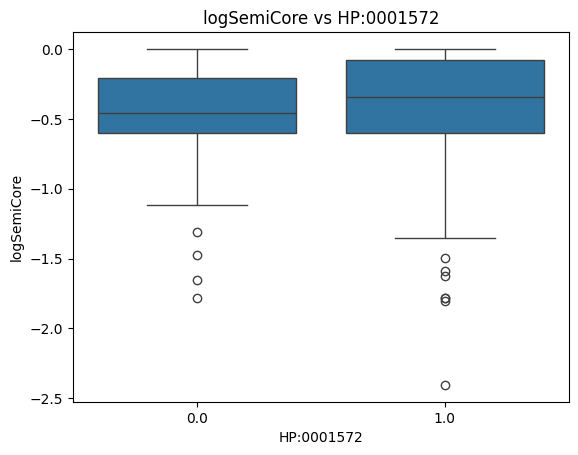

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ph = top5[0]  # or whichever is significant

sns.boxplot(x=df_mech[ph], y=df_mech["logSemiCore"])
plt.title(f"logSemiCore vs {ph}")
plt.show()

In [ ]:
from statsmodels.stats.multitest import multipletests

results_all = []

for pheno in valid_phenos:
    y = df_mech[pheno]
    X = df_mech[["logSemiCore", "TruncFrac"]]
    X = sm.add_constant(X)

    try:
        model = sm.Logit(y, X).fit(disp=0)
        coef = model.params["logSemiCore"]
        pval = model.pvalues["logSemiCore"]
        OR = np.exp(coef)

        results_all.append({
            "phenotype": pheno,
            "coef": coef,
            "OR": OR,
            "pval": pval
        })
    except:
        continue

df_results = pd.DataFrame(results_all)

# FDR correction
df_results["p_fdr"] = multipletests(df_results["pval"], method="fdr_bh")[1]

df_results.sort_values("p_fdr").head(10)

,phenotype,coef,OR,pval,p_fdr
0,HP:0001249,0.563454,1.756730,0.076536,0.639399
9,HP:0004322,-0.553638,0.574854,0.082503,0.639399
12,HP:0001270,1.068625,2.911374,0.023834,0.639399
18,HP:0011968,-0.696089,0.498531,0.047153,0.639399
22,HP:0000308,1.156903,3.180069,0.170544,0.881144
8,HP:0001155,0.444307,1.559408,0.158507,0.881144
11,HP:0002750,-0.448726,0.638441,0.208392,0.922878
2,HP:0007018,0.476763,1.610852,0.259696,0.928347
7,HP:0000343,-0.308436,0.734595,0.326707,0.928347
24,HP:0000664,0.412563,1.510684,0.320286,0.928347


In [ ]:
neuro_terms = [
    "HP:0001249",  # ID
    "HP:0001263",  # global delay
    "HP:0000750"   # speech delay
]

df_mech["NeuroScore"] = df_mech[neuro_terms].sum(axis=1)

In [ ]:
sm.OLS(df_mech["NeuroScore"], sm.add_constant(df_mech[["logSemiCore", "TruncFrac"]])).fit()

In [ ]:
model = sm.OLS(
    df_mech["NeuroScore"],
    sm.add_constant(df_mech[["logSemiCore", "TruncFrac"]])
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             NeuroScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.3699
Date:                Sun, 01 Mar 2026   Prob (F-statistic):              0.691
Time:                        15:27:12   Log-Likelihood:                -392.69
No. Observations:                 256   AIC:                             791.4
Df Residuals:                     253   BIC:                             802.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7171      0.185      9.273      

In [ ]:
model = sm.Logit(
    df_mech["HP:0001249"],
    sm.add_constant(df_mech[["logSemiCore", "logBackbone", "TruncFrac"]])
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.644887
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             HP:0001249   No. Observations:                  256
Model:                          Logit   Df Residuals:                      252
Method:                           MLE   Df Model:                            3
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                 0.03086
Time:                        15:29:06   Log-Likelihood:                -165.09
converged:                       True   LL-Null:                       -170.35
Covariance Type:            nonrobust   LLR p-value:                   0.01466
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2586      0.483     -0.536      0.592      -1.205       0.688
logSemiCore     0.6624    

In [ ]:
np.exp(model.params)

,0
const,0.772126
logSemiCore,1.939408
logBackbone,0.937974
TruncFrac,1.931173


In [ ]:
X_low = pd.DataFrame({
    "const": [1],
    "logSemiCore": [low],
    "logBackbone": [df_mech["logBackbone"].median()],
    "TruncFrac": [df_mech["TruncFrac"].median()]
})

X_high = pd.DataFrame({
    "const": [1],
    "logSemiCore": [high],
    "logBackbone": [df_mech["logBackbone"].median()],
    "TruncFrac": [df_mech["TruncFrac"].median()]
})

In [ ]:
print("Low structural impact probability:",
      model.predict(X_low)[0])

print("High structural impact probability:",
      model.predict(X_high)[0])

Low structural impact probability: 0.6279988986486627
High structural impact probability: 0.7024763258149385


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_mech[["logSemiCore", "logBackbone", "TruncFrac"]]
y = df_mech["HP:0001249"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

tree = DecisionTreeClassifier(
    max_depth=3,      # keep interpretable
    min_samples_leaf=15,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.45      0.37      0.41        27
         1.0       0.69      0.76      0.72        50

    accuracy                           0.62        77
   macro avg       0.57      0.57      0.57        77
weighted avg       0.61      0.62      0.61        77



In [ ]:
import pandas as pd

pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

,0
logSemiCore,0.566427
logBackbone,0.310297
TruncFrac,0.123276


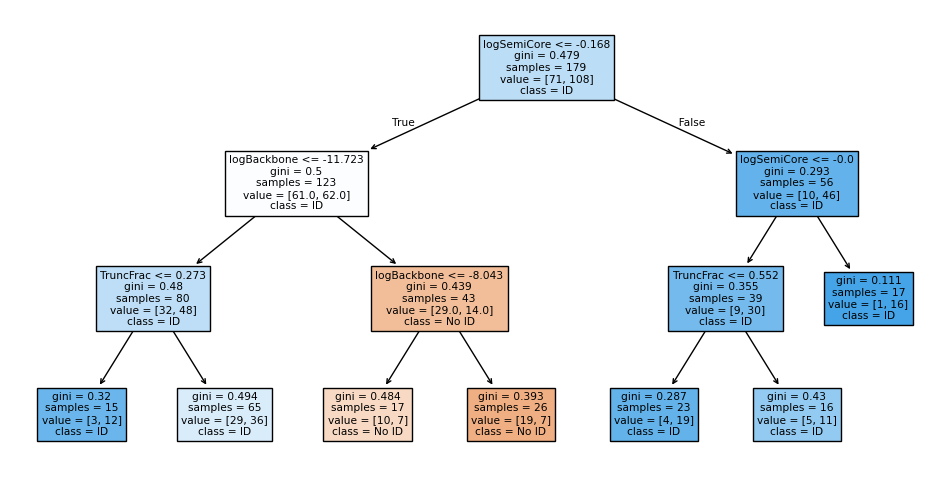

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No ID", "ID"],
    filled=True
)
plt.show()